In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns 

import numpy as np 
import csv

import os

In [2]:
class plot_CHI_energy:
    def __init__(self, data_path,  ):
        self.data_path = data_path

        self.data_matrix = np.array
        self.data_shape = ()

       
    def read_data(self):
        # Read the CSV file
        with open(self.data_path, 'r') as file:
            csv_reader = csv.reader(file)
            data = [list(map(float, row)) for row in csv_reader]

        # Convert the data to a NumPy array
        self.data_matrix = np.array(data)
        print (f'shape of data: {self.data_matrix.shape}')
        
        return(self.data_matrix)
    
    def generate_plot(self, x_label, y_label, title, colorbar_label):

        fig, ax = plt.subplots(figsize=(8,6.5))

        # Create x and y coordinates for the contour plot
        x = np.arange(0, self.data_matrix.shape[1], 1)
        y = np.arange(0, self.data_matrix.shape[0], 1)
        X, Y = np.meshgrid(x, y)

        # Determine the contour levels
        levels = np.arange(np.floor(self.data_matrix.min()), np.ceil(self.data_matrix.max()) + 1, 1)

        # Create a custom colormap from dark blue to blood red
        colors = ['#053061', '#ecf2f5', '#67001f']
        n_bins = 256  # Number of color gradations
        cmap = LinearSegmentedColormap.from_list("custom_blue_red", colors, N=n_bins)

        # Create the filled contour plot
        contourf = ax.contourf(X, Y, self.data_matrix, levels=levels, cmap=cmap)

        # Add contour lines
        contour = ax.contour(X, Y, self.data_matrix, levels=levels, colors='black', linewidths=0.5)

        # Label the contour lines
        ax.clabel(contour, inline=True, fontsize=12, fmt='%1.0f', levels=levels)

        # Add a colorbar
        cbar = fig.colorbar(contourf, ax=ax)
        cbar.set_label(colorbar_label, rotation=90, labelpad=15, fontsize=20)
        cbar.ax.tick_params(labelsize=12)

        # Set x and y axis ticks and labels
        ax.set_xticks(np.arange(0, self.data_matrix.shape[1], 30))
        ax.set_yticks(np.arange(0, self.data_matrix.shape[0], 30))
        ax.tick_params(axis='both', which='both', labelsize=12)  # Set tick font size

        # Add labels and title
        ax.set_xlabel(x_label, fontsize=20)
        ax.set_ylabel(y_label, fontsize=20)
        ax.set_title(title)

        # Show the plot
        plt.tight_layout()
        # plt.savefig('/home/rajan/Desktop/countour_plots_combined_traj/Glca1-4Gal_chiEnergyPlot.png', dpi=550)
        plt.show()               




In [3]:
class analyze_dihedral:
    def __init__(self, data_path_list, link, title):
        self.data_path_list = data_path_list

        self.link = link

        self.title = title

        self.dframe_dihedral = pd.DataFrame()
        
    def generate_dframe_dihrdral(self):
        dfs = []
        # Loop through the files and read them into DataFrames
        for path in self.data_path_list:
            files = os.listdir(path)
            for file in files:
                filepath = os.path.join(path, file)
                column_name = file.split('.')[0]
                df = pd.read_csv(filepath, delimiter='\s+', engine='python')
                df.columns = ['step', column_name]
                # print(column_name)
                dfs.append(df)

        # Concatenate the second column of each DataFrame into a new DataFrame
        dframe_dihedral = pd.concat([df.iloc[:, 1] for df in dfs], axis=1)
        self.dframe_dihedral = dframe_dihedral
    
    def plot_dihedral(self, CHI_matrix):
        link = self.link
        fig, ((ax3, ax4), (ax1, ax2)) = plt.subplots(2, 2, figsize=(10, 10))

        # First create the CHI energy contour plot background
        x = np.arange(0, CHI_matrix.shape[1], 1)
        y = np.arange(0, CHI_matrix.shape[0], 1)
        X, Y = np.meshgrid(x, y)
        levels = np.arange(np.floor(CHI_matrix.min()), np.ceil(CHI_matrix.max()) + 1, 1)
        
        # Create custom colormap
        colors = ['#053061', '#ecf2f5', '#67001f']
        n_bins = 256
        cmap = LinearSegmentedColormap.from_list("custom_blue_red", colors, N=n_bins)
        
        # Create the filled contour plot first (background)
        contourf = ax1.contourf(X, Y, CHI_matrix, levels=levels, cmap=cmap)
        contour = ax1.contour(X, Y, CHI_matrix, levels=levels, colors='black', linewidths=0.5)
        ax1.clabel(contour, inline=True, fontsize=8, fmt='%1.0f', levels=levels)

        # Then plot scatter points
        all_x1_values = []
        all_y1_values = []

        for lnk in link:
            angle_name1 = 'VPS_dihedral_phi-site' + str(lnk)
            angle_name2 = 'VPS_dihedral_psi-site' + str(lnk)

            x1 =[]
            for col in [str(angle_name1), ]:
                for angle_val in self.dframe_dihedral[col]:
                    if angle_val < 0:
                        x1.append(angle_val+360)
                        all_x1_values.append(angle_val+360)
                    else:
                        x1.append(angle_val)
                        all_x1_values.append(angle_val)
                    
            y1 =[]
            for col in [str(angle_name2),]:
                for angle_val in self.dframe_dihedral[col]:                
                    if angle_val < 0:
                        y1.append(angle_val + 360)
                        all_y1_values.append(angle_val+360)
                    else:
                        y1.append(angle_val)
                        all_y1_values.append(angle_val)

        # Plot scatter with '+' marker and increased size for visibility
        ax1.scatter(all_x1_values, all_y1_values, color='blue', marker='+', )

        print('shape of final dots being plotted')
        print(len(all_x1_values),len(all_y1_values))

        # Rest of the plotting code remains the same...
        #####################
        # Plot the histogram of the frequency on the right subplot (ax2)
        sns.histplot(y=all_y1_values, ax=ax2, bins=20, color='blue', kde=True)
        ax2.set_xlabel('Frequency', fontsize=20)
        ax2.set_xlim(xmin=0, xmax=100000)
        ax2.set_ylim(ymin=0, ymax=361)
        ax2.set_yticks(np.arange(0, 360, 30))
        ax3.tick_params(axis='y', which='both', length=0)
        ax2.tick_params(axis='both', which='both', labelleft=False)
        ax2.xaxis.set_major_locator(ticker.MultipleLocator(base=20000))

        #####################
        # Plot the histogram of the frequency on the top subplot (ax3)
        sns.histplot(x=all_x1_values, ax=ax3, bins=20, color='blue', kde=True)
        ax3.set_ylabel('Frequency', fontsize=20)
        ax3.set_ylim(ymin=0, ymax=100000)
        ax3.set_xlim(xmin=0, xmax=361)
        ax3.set_xticks(np.arange(0, 360, 30))
        ax3.tick_params(axis='x', which='both', length=0)
        ax3.tick_params(axis='both', which='both', labelbottom=False)
        ax3.yaxis.set_major_locator(ticker.MultipleLocator(base=20000))

        # Hide ax4 
        ax4.axis('off')    

        #set legend labels 
        ax1.scatter([], [], marker='+', s=5, color='blue', label='')

        #set limit for x and y ticks 
        ax1.set_xlim(xmin=0, xmax=361)
        ax1.set_ylim(ymin=0, ymax=361)
        ax1.set_xticks(np.arange(0, 360, 30))
        ax1.set_yticks(np.arange(0, 360, 30))
        ax3.set_xticks(np.arange(0, 360, 30))

        # set the x and y axis labels
        ax1.set_xlabel('ϕ', fontsize=20)
        ax1.set_ylabel('Ψ', fontsize=20)

        plt.subplots_adjust(wspace=0.01, hspace=0.01)
        fig.suptitle(self.title, fontsize=20)

        # Show grid lines on the plots
        ax1.grid(True)
        ax2.grid(True)
        ax3.grid(True)
        ax4.grid(True)

        # plt.savefig(f'/home/rajan/Desktop/images/{self.title}.png')
        plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_99645/4267102224.py:19: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filepath, delimiter='\s+', engine='python')


In [4]:
##############################################
# dihedral plot for 'DGlcpα(1-4)DGalpα'

shape of data: (361, 361)


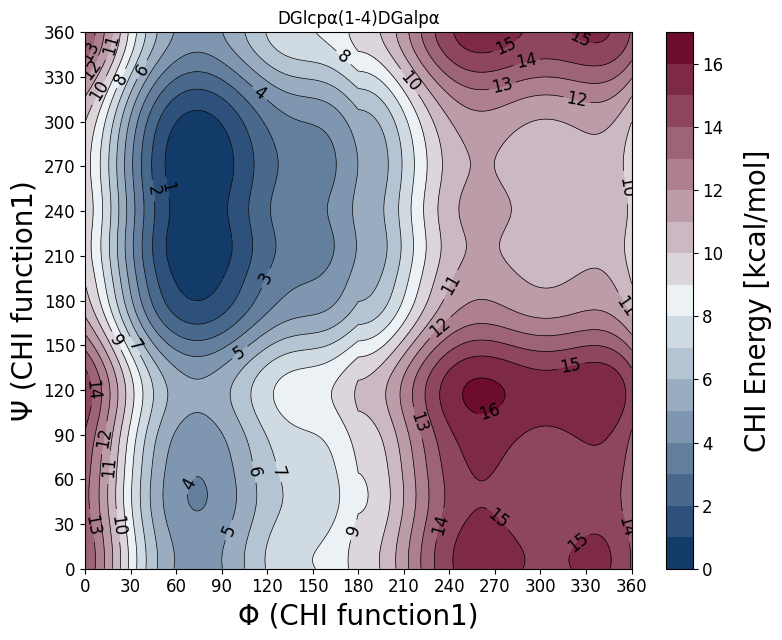

In [5]:
#DGlcpα(1-4)DGalpα
instant1= plot_CHI_energy('./chiEnergyData/Phi1xPsi1.csv', )
CHI_matrix_1x1 =instant1.read_data()
instant1.generate_plot(x_label='Φ (CHI function1)', y_label='Ψ (CHI function1)', title='DGlcpα(1-4)DGalpα', colorbar_label= 'CHI Energy [kcal/mol]')

shape of data: (361, 361)


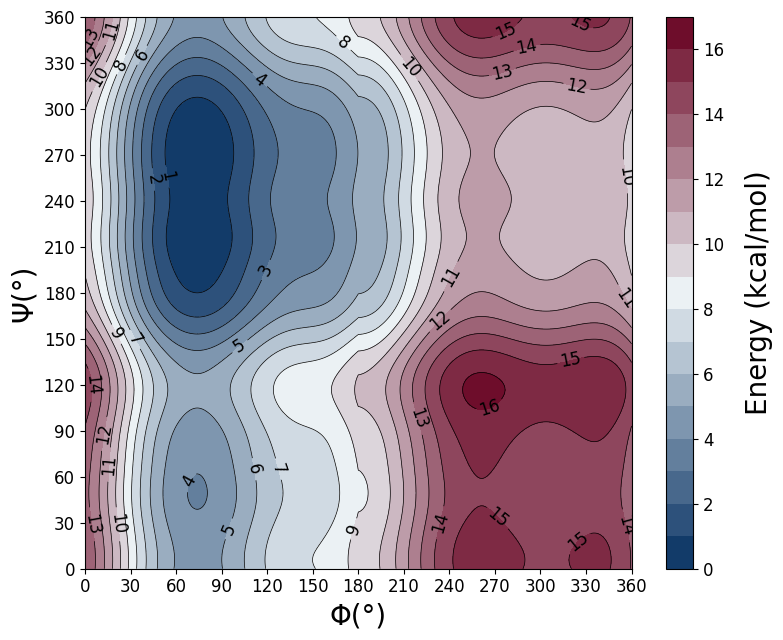

In [6]:
#DGlcpα(1-4)DGalpα
instant1= plot_CHI_energy('./chiEnergyData/Phi1xPsi1.csv', )
CHI_matrix_1x1 =instant1.read_data()
instant1.generate_plot(x_label='Φ(°)', y_label='Ψ(°)', title='', colorbar_label= 'Energy (kcal/mol)')

shape of final dots being plotted
150000 150000


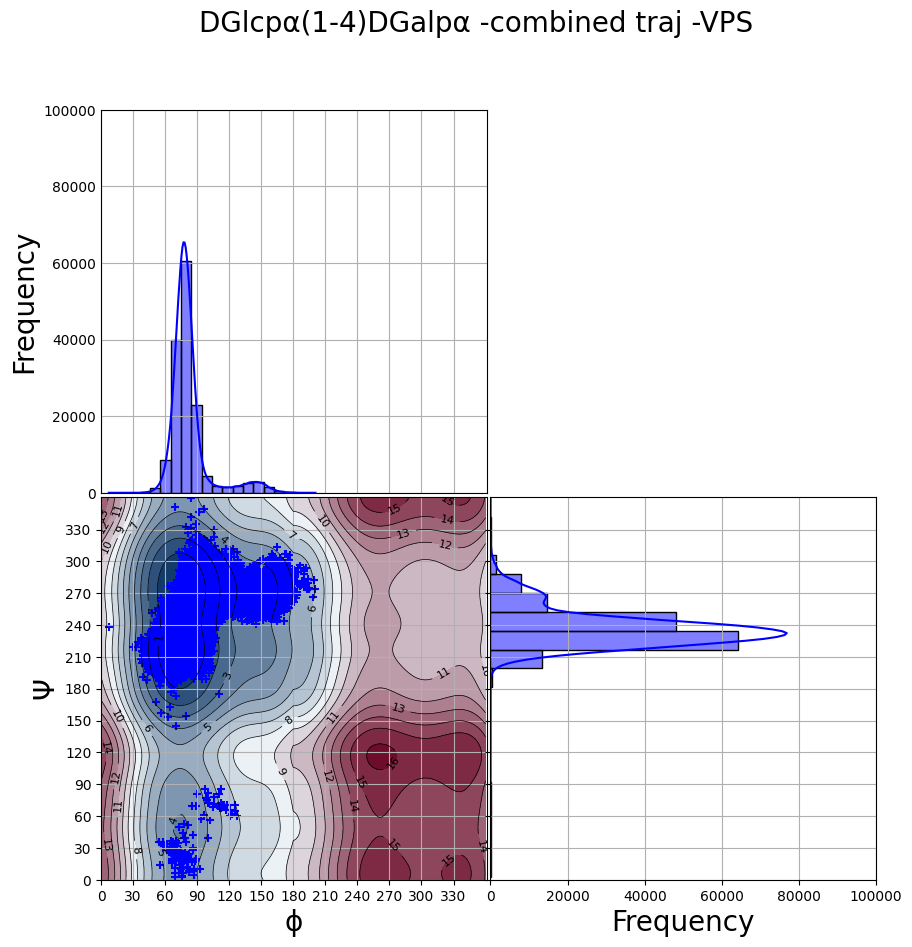

In [7]:
#combine traj
path_list = ["./VPS/replicate_run2"]
link = ['3_2', '9_8', '15_14', '21_20', '27_26', '33_32', '39_38', '45_44', '51_50', '57_56']
title = 'DGlcpα(1-4)DGalpα -combined traj -VPS'
instant1 = analyze_dihedral(path_list, link, title)
instant1.generate_dframe_dihrdral()
instant1.dframe_dihedral.shape
instant1.plot_dihedral(CHI_matrix_1x1)

In [ ]:
##############################################
# dihedral plot for 'DGlcpβ(1-4)DGlcpα'

In [ ]:
#DGlcpβ(1-4)DGlcpα
instant1_1= plot_CHI_energy('/home/rajan/Desktop/CHI_Energies/chiEnergyData/Phi2xPsi2.csv', )
CHI_matrix_2x2 =instant1_1.read_data()
instant1_1.generate_plot(x_label='Φ (CHI function2)', y_label='Ψ (CHI function2)', title='DGlcpβ(1-4)DGlcpα', colorbar_label= 'CHI Energy [kcal/mol]')

In [ ]:
#combine traj
path_list = ["./VPS/replicate_run2"]
link = ['4_3', '10_9', '16_15', '22_21', '28_27', '34_33', '40_39', '46_45', '52_51', '58_57']
title = 'DGlcpβ(1-4)DGlcpα -combined traj -VPS'
instant1 = analyze_dihedral(path_list, link, title)
instant1.generate_dframe_dihrdral()
instant1.dframe_dihedral.shape
instant1.plot_dihedral(CHI_matrix=CHI_matrix_2x2)

In [ ]:
##############################################
# dihedral plot for 'LGulpNAc(3Ac,6Gly)α(1-4)DGlcpβ'

In [ ]:
##############################################
# dihedral plot for 'DGalpα(1-4)LGulpNAc(3Ac,6Gly)'

In [ ]:
######################################################################################################################################################################################################

<h1> for newer phi and psi 3-de-OAc-VPS </h1>

In [ ]:
##############################################
# dihedral plot for 'DGlcpα(1-4)DGalpα'

In [ ]:
#combine traj
path_list = ["./3deOAc_VPS/replicate_run2"]
link = ['3_2', '8_7', '13_12', '18_17', '23_22', '28_27', '33_32', '38_37', '43_42', '48_47']
title = 'DGlcpα(1-4)DGalpα  -combined traj -3deOAc VPS'
instant1 = analyze_dihedral(path_list, link, title)
instant1.generate_dframe_dihrdral()
instant1.dframe_dihedral.shape
instant1.plot_dihedral(CHI_matrix_1x1)

In [ ]:
##############################################
# dihedral plot for 'DGlcpβ(1-4)DGlcpα'

In [ ]:
#combine traj
path_list = ["./3deOAc_VPS/replicate_run2"]
link = ['4_3', '9_8', '14_13', '19_18', '24_23', '29_28', '34_33', '39_38', '44_43', '49_48']
title = 'DGlcpβ(1-4)DGlcpα -combined traj -3deOAc VPS'
instant1 = analyze_dihedral(path_list, link, title)
instant1.generate_dframe_dihrdral()
instant1.dframe_dihedral.shape
instant1.plot_dihedral(CHI_matrix_2x2)

In [ ]:
##############################################
# dihedral plot for 'LGulpNAc(6Gly)α(1-4)DGlcpβ'

In [ ]:
##############################################
# dihedral plot for 'DGalpα(1-4)LGulpNAc(6Gly)'

In [ ]:
######################################################################################################################################################################################################

<h1> for newer phi and psi DGlcpa substituted to DGlcpNAca-VPS </h1>

In [ ]:
##############################################
# dihedral plot for 'DGlcpNAcα(1-4)DGalpα'

In [ ]:
#combine traj
path_list = ["./GlcpNAca_substitution_VPS/replicate_run2"]
link = ['3_2', '9_8', '15_14', '21_20', '27_26', '33_32', '39_38', '45_44', '51_50', '57_56']
title = 'DGlcpNAcα(1-4)DGalpα -combined traj -DGlcpNAca subs VPS'
instant1 = analyze_dihedral(path_list, link, title)
instant1.generate_dframe_dihrdral()
instant1.dframe_dihedral.shape
instant1.plot_dihedral(CHI_matrix_1x1)

In [ ]:
##############################################
# dihedral plot for 'DGlcpβ(1-4)DGlcpNAcα' 

In [ ]:
#combine traj
path_list = ["./GlcpNAca_substitution_VPS/replicate_run2"]
link = ['4_3', '10_9', '16_15', '22_21', '28_27', '34_33', '40_39', '46_45', '52_51', '58_57']
title = 'DGlcpβ(1-4)DGlcpNAcα -combined traj -DGlcpNAca subs VPS'
instant1 = analyze_dihedral(path_list, link, title)
instant1.generate_dframe_dihrdral()
instant1.dframe_dihedral.shape
instant1.plot_dihedral(CHI_matrix_2x2)

In [ ]:
##############################################
# dihedral plot for 'LGulpNAc(3Ac,6Gly)α(1-4)DGlcpβ'

In [ ]:
##############################################
# dihedral plot for 'DGalpα(1-4)LGulpNAc(3Ac,6Gly)'